# Preparing Ground Truth Data

Based on the paper,

$\alpha = 9.868 \times 10^{-5}$

$k = 237$ W/mK (estimated)

$\Delta x = 0.001$ m

$\Delta t = 1$ s

$$



##  CASE 1 : Constant Heat Flux

$q_0 = 10,000$ W/m^2

$t \in [0,3600]$ seconds

$x \in [0,1]$ m

For PINN training, $2200$ points were randomly chosen out of $48441 (201 \times 241)$ Generated Dataset

Means we first need to generate (201 \times 241)$ Dataset


Notice that if we generate dataset based on above $\Delta x$ and $\Delta t$ , we will have $1001 \times 3600$ Data points which is 3.6 Million

Looking at the Numbers from paper, it seems while generation, they used 

$\Delta x' = 5 \Delta x = 0.005$ m

$\Delta t' = 15 \Delta t = 15$ s

In this way, we will have (1/0.005 + 1) $\times$ (3600/15 + 1) or $201 \times 241$ points (This wasn't mentioned in paper, it is purely speculated)

### Problem description

We have 

$$
    \alpha \frac{\partial^2 T}{\partial x^2} = \frac{\partial T}{\partial t}
$$

where 

$$
T(x,t) = \tilde{T}(x,t) - T_0
$$

$\tilde{T}(x,t)$ is Temperature at location $x$ and time $t$

and

$T_0$ is $T(x,0)$ which is same throughout initially 

and

We have boundary conditions as 

$$
\begin{gather*}
-\left. k\frac{\partial T}{\partial x} \right|_{x=0} = q_0 \qquad -\left. k\frac{\partial T}{\partial x} \right|_{x=L} = 0
\end{gather*}
$$


Now, the analytical formula we will be using for Ground Truth (derived from Green's Function ) 


$$
\tilde{T}(x,t) = T_0 + \frac{\alpha q_0 t}{k L} + \frac{2 q_0}{k L} \sum_{n=1}^{\infty} \left( \frac{cos(\gamma_n x)[1 - e^{-\alpha \gamma_n^2 t}]}{\gamma_n^2}\right)
$$


where 

- $L = 1$ m

- $\gamma_n = \frac{n \pi}{L}$ for n = 0,1,2,3,...


As we can't sum from $n=1$ to $n= \infty$ in practice, we sum to $n = m$ for some large value of $m$. This $m$ is also called as Number of eigenvalues used in analytical solution. 


In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [2]:


dx = 0.005
dt = 15

x_list = np.linspace(0,1,int(1/dx)+1,endpoint=True)



def generate_gt_const(q0,alpha,k,T0,L,m,dt) :
    const_data = []
    for t in range(0,3600+dt,dt) :
        T_tilde = T0 + (alpha*q0*t)/(k*L) + (2*q0)/(k*L)*sum((np.cos(n*np.pi*x_list/L)*(1-np.exp(-alpha*(n*np.pi/L)**2*t)))/(n*np.pi/L)**2 for n in range(1,m+1))
        const_data.append(T_tilde)

    const_data = np.array(const_data)
    return const_data


q0 = 10_000
alpha = 9.868e-5
k = 237
T0 = 0
L = 1
m = 500
const_data = generate_gt_const(q0,alpha,k,T0,L,m,dt)


In [3]:
print(const_data.shape)

print(const_data)

(241, 201)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.81466947e+00  1.63052142e+00  1.44077834e+00 ... -1.70664122e-05
  -1.34309925e-07  1.70664206e-05]
 [ 2.57340641e+00  2.38699652e+00  2.19050992e+00 ... -1.70664122e-05
  -1.34309924e-07  1.70664206e-05]
 ...
 [ 2.86478474e+01  2.84565304e+01  2.82453456e+01 ...  8.09828763e+00
   8.09682006e+00  8.09634243e+00]
 [ 2.87141351e+01  2.85228177e+01  2.83116314e+01 ...  8.15691339e+00
   8.15544440e+00  8.15496630e+00]
 [ 2.87803673e+01  2.85890494e+01  2.83778617e+01 ...  8.21559469e+00
   8.21412431e+00  8.21364574e+00]]


In [4]:
print(const_data[220]) # using 3300/3600*240 = 220

[27.44416981 27.25286263 27.04170719 26.8327523  26.62647139 26.4210798
 26.21594155 26.01206956 25.80996365 25.60891093 25.40851146 25.20931765
 25.01165851 24.81508055 24.61930586 24.42471969 24.23156034 24.03949099
 23.84830329 23.6582962  23.46965277 23.28210245 23.09548153 22.91003625
 22.72591256 22.54288267 22.36081392 22.17991693 22.00031103 21.82179831
 21.64426896 21.46790791 21.29281441 21.11881262 20.94581032 20.77397294
 20.60338403 20.4338848  20.2653969  20.09807052 19.93197654 19.76696972
 19.60298303 19.44015431 19.27854404 19.11801801 18.95851859 18.80017344
 18.64303429 18.48697613 18.33194926 18.17807278 18.02539095 17.87378655
 17.7232167  17.57379316 17.42555375 17.27838794 17.13225876 16.98727165
 16.84345876 16.7007154  16.55900979 16.41844182 16.27903865 16.1407007
 16.00340084 15.86723401 15.73222293 15.59827258 15.46535994 15.33357559
 15.20293824 15.07335694 14.94481242 14.81739129 14.69110865 14.56587725
 14.44168117 14.31860348 14.19665596 14.07575472 13.9

Plotting the above temperature profile (i.e. at t = 3300 s)

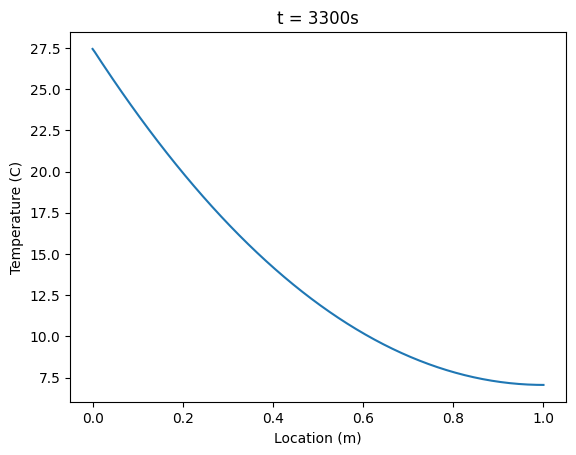

In [5]:
plt.plot(x_list,const_data[220])

plt.xlabel('Location (m)')
plt.ylabel('Temperature (C)')
plt.title('t = 3300s')


plt.show()

This matches with the graph at $t = 3300$ s given in paper

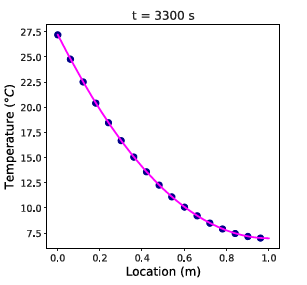

Hence, we can say we have generated this dataset pretty well



In [6]:
print('Max :',np.max(const_data))
print('Min : ',np.min(const_data))

Max : 28.780367308262182
Min :  -3.912509881164733e-05


## CASE 2 : Linear Heat Flux

$q(t) = 10000 + 5t$ W/m^2

$t \in [0,2000]$ seconds

$x \in [0,1]$ m

In paper, it was not given exactly how many datapoints were generated for this case, so we just assume  as follows : 

as x is same we repeat everything for x i.e. 

$\Delta x' = 5 \Delta x = 0.005$ m

i.e. we will have (1/0.005 + 1) = 201 spatial points

$\Delta t' = 5 \Delta t = 5$ s

i.e. we will have (2000/5 + 1) = 401 spatial points

Means we first need to generate $201 \times 401$ Dataset

<!-- and for PINN training, $4400$ points will randomly chosen out of $80601 (201 \times 401)$ Generated Dataset (again assumed, not given in paper) -->

### Problem description

Same as above except left boundary condition is given as 

$$
\begin{gather*}
-\left. k\frac{\partial T}{\partial x} \right|_{x=0} = q_0 + q_1 t 
\end{gather*}
$$

where $q_0 = 10000$, $q_1 = 5$ and $ t \in [0,2000]$

Now, Analytical solution to this system (found using Green's function) can be written as 

$$
\tilde{T}(x,t) = T_0 + \frac{\alpha q_0 t}{k L} + \frac{\alpha q_1 t^2}{2 k L} + \frac{2 q_0}{k L} \sum_{n=1}^{\infty} \left( \frac{cos(\gamma_n x)[1 - e^{-\alpha \gamma_n^2 t}]}{\gamma_n^2}\right) + \frac{2 q_1}{\alpha k L} \sum_{n=1}^{\infty} \left( \frac{cos(\gamma_n x)[\alpha \gamma_n^2 t - 1 + e^{-\alpha \gamma_n^2 t}]}{\gamma_n^4}\right)
$$


Again, as we can't sum from $n=1$ to $n= \infty$ in practice, we sum to $n = m$ for some large value of $m$.


In [7]:
dx = 0.005
dt = 1

x_list = np.linspace(0,1,int(1/dx)+1,endpoint=True)



def generate_gt_linear(q0,q1,alpha,k,T0,L,m,dt) :
    linear_data = []
    for t in range(0,2000+dt,dt) :
        def g(n) : return (n*np.pi/L)
        T_tilde = T0 + (alpha*q0*t)/(k*L) + (alpha*q1*t**2)/(2*k*L) + (2*q0)/(k*L)*sum((np.cos(g(n)*x_list)*(1-np.exp(-alpha*(g(n))**2*t)))/(g(n))**2 for n in range(1,m+1)) \
              + (2*q1)/(alpha*k*L)*sum((np.cos(g(n)*x_list)*( alpha*(g(n)**2)*t - 1 + np.exp(-alpha*(g(n)**2)*t)))/(g(n)**4) for n in range(1,m+1))
        linear_data.append(T_tilde)

    linear_data = np.array(linear_data)
    return linear_data


q0 = 10_000
q1 = 5
alpha = 9.868e-5
k = 237
T0 = 0
L = 1
m = 500
linear_data = generate_gt_linear(q0,q1,alpha,k,T0,L,m,dt)

In [8]:
print(linear_data.shape)

print(linear_data[-1]) # Checking at t = 2000s

(2001, 201)
[35.24142323 34.85968397 34.43998067 34.02638445 33.61981578 33.21667908
 32.8156763  32.41880735 32.02704599 31.6389408  31.25366633 30.87230203
 30.4954806  30.12226996 29.75208929 29.38568425 29.02350672 28.66485846
 28.30929836 27.95740003 27.60950541 27.26504937 26.92368064 26.58586791
 26.25187952 25.92123637 25.59364985 25.26951799 24.94905641 24.63184636
 24.31764547 24.00680092 23.69948873 23.3953349  23.09413269 22.79619094
 22.50165476 22.21018479 21.92160265 21.63618717 21.35405875 21.07490563
 20.79857264 20.52531448 20.25523125 19.98803387 19.72358647 19.46212396
 19.2037295  18.94813292 18.69521482 18.4451935  18.19813775 17.95379353
 17.71205561 17.47312821 17.23706774 17.0036341  16.77273446 16.54456089
 16.31915907 16.0963011  15.87590509 15.65815255 15.44307973 15.23046953
 15.02024983 14.81259286 14.60752652 14.40484335 14.20448007 14.00660066
 13.81122557 13.61815605 13.42733682 13.23892451 13.05293289 12.86917111
 12.6875912  12.50834322 12.33143486 12

Plotting the above temperature profile (i.e. at t = 2000)

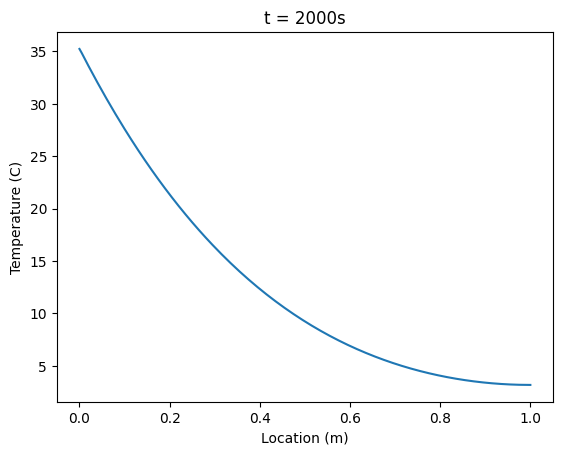

In [9]:
plt.plot(x_list,linear_data[-1])

plt.xlabel('Location (m)')
plt.ylabel('Temperature (C)')
plt.title('t = 2000s')


plt.show()

This matches well with dataset from paper 

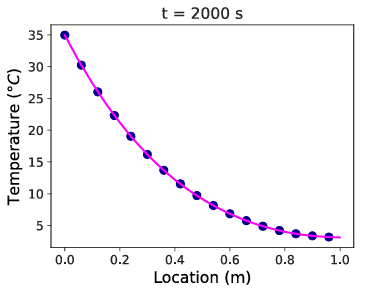

In [10]:
print('Max :',np.max(linear_data))
print('Min : ',np.min(linear_data))

Max : 35.241423234137415
Min :  -0.00018507898800460042


## CASE 3 : Sinusoidal Heat Flux

$q(t) = 15000 + 10000 \text{sin}(\omega t)$ W/m^2

$t \in [0,1600]$ seconds

$x \in [0,1]$ m

as given in paper that one complete revolution happens in 1600 second, that means 

$ \omega = \frac{2 \pi}{T} = \frac{2 \pi}{1600} = 0.003927 $ 

In paper, again it was not given exactly how many datapoints were generated for this case, so we just assume  as follows : 

as x is same we repeat everything for x i.e. 

$\Delta x' = 5 \Delta x = 0.005$ m

i.e. we will have (1/0.005 + 1) = 201 spatial points

$\Delta t' = 4 \Delta t = 4$ s

i.e. we will have (1600/4 + 1) = 401 spatial points

Means we first need to generate $201 \times 401$ Dataset

<!-- and again for PINN training, $4400$ points will randomly chosen out of $80601 (201 \times 401)$ Generated Dataset  -->

### Problem description

Same as above except left boundary condition is given as 

$$
\begin{gather*}
-\left. k\frac{\partial T}{\partial x} \right|_{x=0} = q_0 + q_1 \text{sin}(\omega t) 
\end{gather*}
$$

where $q_0 = 15000$, $q_1 = 10000$ and $ t \in [0,1600]$

Now, Analytical solution to this system (found using Green's function) can be written as 

$$
\tilde{T}(x,t) = T_0 + \frac{\alpha q_0 t}{k L} + \frac{\alpha q_1}{k L} + \frac{2 q_0}{k L} \sum_{n=1}^{\infty} \left( \frac{cos(\gamma_n x)[1 - e^{-\alpha \gamma_n^2 t}]}{\gamma_n^2}\right) + \frac{2 \alpha q_1}{ k L} \sum_{n=1}^{\infty} \left( \frac{cos(\gamma_n x)[\alpha \gamma_n^2 \text{sin}(\omega t) - \omega \text{cos}(\omega t) + \omega e^{-\alpha \gamma_n^2 t}]}{(\alpha \gamma_n^2)^2 + \omega^2}\right)
$$


Again, as we can't sum from $n=1$ to $n= \infty$ in practice, we sum to $n = m$ for some large value of $m$.


In [11]:
dx = 0.005
dt = 1

x_list = np.linspace(0,1,int(1/dx)+1,endpoint=True)



def generate_gt_sinusoidal(q0,q1,omega,alpha,k,T0,L,m,dt) :
    sinusoidal_data = []
    for t in range(0,1600+dt,dt) :
        def g(n) : return (n*np.pi/L)
        T_tilde = T0 + (alpha*q0*t)/(k*L) + (alpha*q1)/(k*L) + (2*q0)/(k*L)*sum((np.cos(g(n)*x_list)*(1-np.exp(-alpha*(g(n))**2*t)))/(g(n))**2 for n in range(1,m+1)) \
              + (2*alpha*q1)/(k*L)*sum((np.cos(g(n)*x_list)*( alpha*(g(n)**2)*np.sin(omega*t) - omega*np.cos(omega*t) + omega*np.exp(-alpha*(g(n)**2)*t)))/((alpha*g(n)**2)**2 + omega**2) for n in range(1,m+1))
        sinusoidal_data.append(T_tilde)

    sinusoidal_data = np.array(sinusoidal_data)
    return sinusoidal_data


q0 = 15_000
q1 = 10_000
omega = 0.003927
alpha = 9.868e-5
k = 237
T0 = 0
L = 1
m = 500
sinusoidal_data = generate_gt_sinusoidal(q0,q1,omega,alpha,k,T0,L,m,dt)

In [12]:
print(sinusoidal_data.shape)

print(sinusoidal_data[1200]) # (1200/1600*1600 = 1200)

(1601, 201)
[20.47460681 20.37753222 20.26769368 20.15612204 20.04306452 19.92764313
 19.80955791 19.68933685 19.56725463 19.44298277 19.31635214 19.18767263
 19.05714497 18.92458117 18.78988325 18.65328702 18.51495679 18.37477114
 18.23267465 18.08886712 17.94349184 17.79646665 17.647764   17.49756242
 17.34599128 17.19299392 17.03856203 16.88285961 16.72600556 16.56796063
 16.40873001 16.24846654 16.08728044 15.92514451 15.76207339 15.59821055
 15.43365841 15.26839805 15.10245058 14.93595104 14.76899452 14.60156762
 14.4336956  14.26550564 14.09708572 13.92842584 13.75955369 13.59058888
 13.42161239 13.25261605 13.08362857 12.91476224 12.74609111 12.57760759
 12.4093404  12.24139465 12.07383753 11.90666112 11.73989332 11.57363221
 11.40793827 11.24280252 11.07825144 10.91437627 10.75123089 10.58880475
 10.42712247 10.26626868 10.10629082  9.94717641  9.78894792  9.63168357
  9.47542458  9.32015632  9.16589893  9.01272446  8.86066819  8.70971316
  8.5598771   8.41122621  8.26379005  8

Plotting the above temperature profile (i.e. at t = 1200)

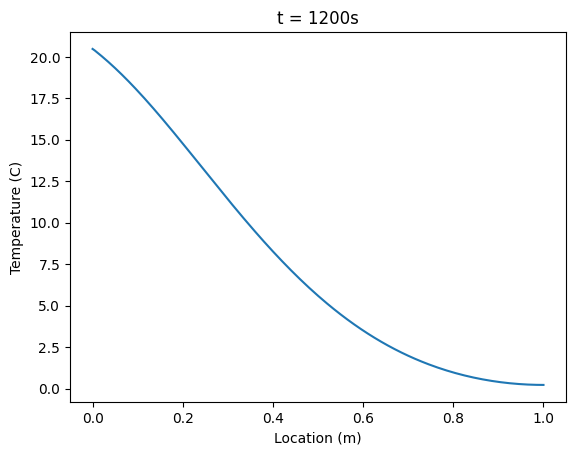

In [13]:
plt.plot(x_list,sinusoidal_data[1200])

plt.xlabel('Location (m)')
plt.ylabel('Temperature (C)')
plt.title('t = 1200s')


plt.show()

This matches well with the graph at $t = 1200$ s given in paper

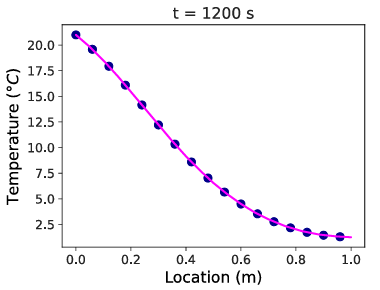

In [14]:
print('Max :',np.max(sinusoidal_data))
print('Min : ',np.min(sinusoidal_data))

Max : 25.116385644733764
Min :  -1.9166590369522813


## Noisy Temperature profile (GT)

### For constant case

In [15]:
data = const_data
col_std = np.std(data,axis=0,keepdims=True)

rng = np.random.default_rng(seed=43)

M,N = data.shape
const_data_noisy = data + 0.10 * col_std * rng.standard_normal((M,N))

In [16]:
np.savez('const_gt.npz',saved_data=const_data)
np.savez('const_gt_noisy.npz',saved_data=const_data_noisy)


### For linear case

In [17]:
data = linear_data
col_std = np.std(data,axis=0,keepdims=True)

rng = np.random.default_rng(seed=42)

M,N = data.shape
linear_data_noisy = data + 0.10 * col_std * rng.standard_normal((M,N))

In [18]:
np.savez('linear_gt.npz',saved_data=linear_data)
np.savez('linear_gt_noisy.npz',saved_data=linear_data_noisy)

### For sinusoidal case

In [19]:
data = sinusoidal_data
col_std = np.std(data,axis=0,keepdims=True)


rng = np.random.default_rng(seed=42)

M,N = data.shape
sinusoidal_data_noisy = data + 0.10 * col_std * rng.standard_normal((M,N))

In [20]:
np.savez('sinusoidal_gt.npz',saved_data=sinusoidal_data)
np.savez('sinusoidal_gt_noisy.npz',saved_data=sinusoidal_data_noisy)

# Preparing the Data for PINN 

## CASE 1 : Constant Heat Flux


For this case, we have to choose 2200 points randomly out of 48441 generated points.


Note that generated dataset is of form 


And we need to change it to the form 


We then need to choose 2200 points randomly from this matrix and keep it in the list 



In [56]:
(M,N) = const_data.shape

dx = 0.005
dt = 15


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))
print(i_grid)
print(j_grid)


[[  0   0   0 ...   0   0   0]
 [  1   1   1 ...   1   1   1]
 [  2   2   2 ...   2   2   2]
 ...
 [238 238 238 ... 238 238 238]
 [239 239 239 ... 239 239 239]
 [240 240 240 ... 240 240 240]]
[[  0   1   2 ... 198 199 200]
 [  0   1   2 ... 198 199 200]
 [  0   1   2 ... 198 199 200]
 ...
 [  0   1   2 ... 198 199 200]
 [  0   1   2 ... 198 199 200]
 [  0   1   2 ... 198 199 200]]


In [57]:
print(i_grid*dt)
print(j_grid*dx)

[[   0    0    0 ...    0    0    0]
 [  15   15   15 ...   15   15   15]
 [  30   30   30 ...   30   30   30]
 ...
 [3570 3570 3570 ... 3570 3570 3570]
 [3585 3585 3585 ... 3585 3585 3585]
 [3600 3600 3600 ... 3600 3600 3600]]
[[0.    0.005 0.01  ... 0.99  0.995 1.   ]
 [0.    0.005 0.01  ... 0.99  0.995 1.   ]
 [0.    0.005 0.01  ... 0.99  0.995 1.   ]
 ...
 [0.    0.005 0.01  ... 0.99  0.995 1.   ]
 [0.    0.005 0.01  ... 0.99  0.995 1.   ]
 [0.    0.005 0.01  ... 0.99  0.995 1.   ]]


In [58]:
mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = const_data


print(mapped_matrix)

[[(0.   ,    0.,  0.00000000e+00) (0.005,    0.,  0.00000000e+00)
  (0.01 ,    0.,  0.00000000e+00) ... (0.99 ,    0.,  0.00000000e+00)
  (0.995,    0.,  0.00000000e+00) (1.   ,    0.,  0.00000000e+00)]
 [(0.   ,   15.,  1.81466947e+00) (0.005,   15.,  1.63052142e+00)
  (0.01 ,   15.,  1.44077834e+00) ... (0.99 ,   15., -1.70664122e-05)
  (0.995,   15., -1.34309925e-07) (1.   ,   15.,  1.70664206e-05)]
 [(0.   ,   30.,  2.57340641e+00) (0.005,   30.,  2.38699652e+00)
  (0.01 ,   30.,  2.19050992e+00) ... (0.99 ,   30., -1.70664122e-05)
  (0.995,   30., -1.34309924e-07) (1.   ,   30.,  1.70664206e-05)]
 ...
 [(0.   , 3570.,  2.86478474e+01) (0.005, 3570.,  2.84565304e+01)
  (0.01 , 3570.,  2.82453456e+01) ... (0.99 , 3570.,  8.09828763e+00)
  (0.995, 3570.,  8.09682006e+00) (1.   , 3570.,  8.09634243e+00)]
 [(0.   , 3585.,  2.87141351e+01) (0.005, 3585.,  2.85228177e+01)
  (0.01 , 3585.,  2.83116314e+01) ... (0.99 , 3585.,  8.15691339e+00)
  (0.995, 3585.,  8.15544440e+00) (1.   , 3585.

Exactly of the form we wanted

In [59]:
k = 2200

rng = np.random.default_rng(seed=42) # 67 for val

const_data_pinn = rng.choice(mapped_matrix.ravel(), size=k, replace=False)

print(const_data_pinn.shape)
print(const_data_pinn)

(2200,)
[(0.58 ,  570., 0.48191505) (0.36 , 1965., 9.25429917)
 (0.995, 2955., 5.75281457) ... (0.745, 2355., 4.74543597)
 (0.52 , 2790., 9.48069095) (0.51 ,  315., 0.15802518)]


Now all we need to do is save this dataset

In [25]:
np.savez('const_pinn_data.npz',saved_data=const_data_pinn)


### Noisy PINN data for constant case

In [26]:
(M,N) = const_data_noisy.shape

dx = 0.005
dt = 15


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))

mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = const_data_noisy


k = 2200

rng = np.random.default_rng(seed=42) # 67 for val

const_data_pinn_noisy = rng.choice(mapped_matrix.ravel(), size=k, replace=False)

print(const_data_pinn_noisy.shape)
print(const_data_pinn_noisy)



(2200,)
[(0.58 ,  570.,  0.38202704) (0.36 , 1965.,  9.10641101)
 (0.995, 2955.,  5.76588136) ... (0.745, 2355.,  4.99376665)
 (0.52 , 2790.,  8.85830791) (0.51 ,  315., -0.10509613)]


In [27]:
np.savez('const_pinn_data_noisy.npz',saved_data=const_data_pinn_noisy)

## CASE 2 : Linear Heat Flux


In [60]:
(M,N) = linear_data.shape

dx = 0.005
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])

i_grid, j_grid = np.indices((M, N))

mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = linear_data

In [29]:
print(mapped_matrix)

[[(0.   , 0.000e+00,  0.00000000e+00) (0.005, 0.000e+00,  0.00000000e+00)
  (0.01 , 0.000e+00,  0.00000000e+00) ...
  (0.99 , 0.000e+00,  0.00000000e+00) (0.995, 0.000e+00,  0.00000000e+00)
  (1.   , 0.000e+00,  0.00000000e+00)]
 [(0.   , 1.000e+00,  4.56022182e-01) (0.005, 1.000e+00,  2.93717982e-01)
  (0.01 , 1.000e+00,  1.66173691e-01) ...
  (0.99 , 1.000e+00, -1.70749104e-05) (0.995, 1.000e+00, -1.34376804e-07)
  (1.   , 1.000e+00,  1.70749188e-05)]
 [(0.   , 2.000e+00,  6.52206931e-01) (0.005, 2.000e+00,  4.81246589e-01)
  (0.01 , 2.000e+00,  3.30179272e-01) ...
  (0.99 , 2.000e+00, -1.70834436e-05) (0.995, 2.000e+00, -1.34443959e-07)
  (1.   , 2.000e+00,  1.70834520e-05)]
 ...
 [(0.   , 1.998e+03,  3.52095623e+01) (0.005, 1.998e+03,  3.48280145e+01)
  (0.01 , 1.998e+03,  3.44085229e+01) ...
  (0.99 , 1.998e+03,  3.16961992e+00) (0.995, 1.998e+03,  3.16804573e+00)
  (1.   , 1.998e+03,  3.16754413e+00)]
 [(0.   , 1.999e+03,  3.52254920e+01) (0.005, 1.999e+03,  3.48438485e+01)
  (0.

Now, we have to be a bit careful here when random sampling. In cases of time-variant heat flux (linear and sinusoidal), PINN model was trained on one temporal point and many spatial points at a time to get predicted heat flux at that time

Then this was repeeated for many temporal points 

In case of linear heat flux, temporal points were 0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000 seconds, each having 201 spatial points 

each having indices 0, 250/2000 $\times$ 400,  500/2000 $\times$ 400, ...

In [30]:
temporal_points_linear = np.concatenate((np.array([1]),np.linspace(250,2000,8,endpoint=True))) # Approximating t = 0s with t = 1s

linear_data_pinn = []

for p in temporal_points_linear :
    linear_data_pinn.append(mapped_matrix[int(p*2000/2000)])

linear_data_pinn = np.array(linear_data_pinn).flatten()

print(linear_data_pinn.shape)

print(linear_data_pinn)

print(linear_data_pinn[199]) # should show with t = 1

print(linear_data_pinn[203]) # should show with t = 250



(1809,)
[(0.   , 1.e+00, 0.45602218) (0.005, 1.e+00, 0.29371798)
 (0.01 , 1.e+00, 0.16617369) ... (0.99 , 2.e+03, 3.17809028)
 (0.995, 2.e+03, 3.1765141 ) (1.   , 2.e+03, 3.17601185)]
(0.995, 1.0, -1.3437680380637194e-07)
(0.01, 250.0, 7.636157788578843)


Now all we need to do is save this dataset

In [31]:
np.savez('linear_pinn_data.npz',saved_data=linear_data_pinn)

### Noisy PINN data for linear case

In [32]:
(M,N) = linear_data_noisy.shape

dx = 0.005
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])

i_grid, j_grid = np.indices((M, N))

mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = linear_data_noisy


temporal_points_linear = np.concatenate((np.array([1]),np.linspace(250,2000,8,endpoint=True)))

linear_data_pinn_noisy = []

for p in temporal_points_linear :
    linear_data_pinn_noisy.append(mapped_matrix[int(p*2000/2000)])

linear_data_pinn_noisy = np.array(linear_data_pinn_noisy).flatten()

print(linear_data_pinn_noisy.shape)

print(linear_data_pinn_noisy)

print(linear_data_pinn_noisy[199]) # should show with t = 1

print(linear_data_pinn_noisy[203]) # should show with t = 250

(1809,)
[(0.   , 1.e+00, 1.7353215 ) (0.005, 1.e+00, 0.37554569)
 (0.01 , 1.e+00, 0.74380237) ... (0.99 , 2.e+03, 3.26595581)
 (0.995, 2.e+03, 3.12899884) (1.   , 2.e+03, 3.12944766)]
(0.995, 1.0, -0.0168162051507118)
(0.01, 250.0, 7.675436763242588)


In [33]:
np.savez('linear_pinn_data_noisy.npz',saved_data=linear_data_pinn_noisy)

## CASE 3 : Sinusoidal Heat Flux


Training is done in same way as case 2

In this case of sinusoidal heat flux, temporal points were 0, 200, 400, 600, 800, 1000, 1200, 1400, 1600 seconds, each having 201 spatial points 

each having indices 0, 200/1600 $\times$ 400,  400/1600 $\times$ 400, ...


In [34]:
(M,N) = sinusoidal_data.shape

dx = 0.005
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])

i_grid, j_grid = np.indices((M, N))

mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = sinusoidal_data



In [35]:
temporal_points_sinusoidal = np.array([1,160,400,640,800,960,1200,1440,1600])

sinusoidal_data_pinn = []

for p in temporal_points_sinusoidal :
    sinusoidal_data_pinn.append(mapped_matrix[int(p*1600/1600)])

sinusoidal_data_pinn = np.array(sinusoidal_data_pinn).flatten()

print(sinusoidal_data_pinn.shape)

print(sinusoidal_data_pinn)

print(sinusoidal_data_pinn[199]) # should show with t = 1

print(sinusoidal_data_pinn[202]) # should show with t = 160



(1809,)
[(0.   , 1.0e+00, 0.68913633) (0.005, 1.0e+00, 0.44523438)
 (0.01 , 1.0e+00, 0.25364421) ... (0.99 , 1.6e+03, 2.91906417)
 (0.995, 1.6e+03, 2.91743616) (1.   , 1.6e+03, 2.91691082)]
(0.995, 1.0, 0.004155335649887672)
(0.005, 160.0, 10.739983471274213)


Now all we need to do is save this dataset

In [36]:
np.savez('sinusoidal_pinn_data.npz',saved_data=sinusoidal_data_pinn)


### Noisy PINN data

In [37]:
(M,N) = sinusoidal_data_noisy.shape

dx = 0.005
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])

i_grid, j_grid = np.indices((M, N))

mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = sinusoidal_data_noisy

temporal_points_sinusoidal = np.array([1,160,400,640,800,960,1200,1440,1600])

sinusoidal_data_pinn_noisy = []

for p in temporal_points_sinusoidal :
    sinusoidal_data_pinn_noisy.append(mapped_matrix[int(p*1600/1600)])

sinusoidal_data_pinn_noisy = np.array(sinusoidal_data_pinn_noisy).flatten()


print(sinusoidal_data_pinn_noisy[199]) # should show with t = 1

print(sinusoidal_data_pinn_noisy[202]) # should show with t = 160


(0.995, 1.0, -0.02049213762022128)
(0.005, 160.0, 10.93554953920777)


In [38]:
np.savez('sinusoidal_pinn_data_noisy.npz',saved_data=sinusoidal_data_pinn_noisy)


# Rough estimation of q and alpha for initial values as model parameter in PINN training 

### SubCase 1.1 : Constant Heat Flux with No noise

In [39]:
dx = 0.005
dT_dx = (const_data[:,2] - const_data[:,0])/(2*dx)

dT_dx_av = np.sum(dT_dx,axis=0)/241

k = 237 # (got from estimation)

print(f"Estimated q value comes out to be : {-k*dT_dx_av}")

Estimated q value comes out to be : 9461.274561602022


### SubCase 1.2 : Constant Heat Flux with 10 % noise

In [40]:
dx = 0.005
dT_dx = (const_data_noisy[:,2] - const_data_noisy[:,0])/(2*dx)

dT_dx_av = np.sum(dT_dx,axis=0)/241

k = 237 # (got from estimation)

print(f"Estimated q value comes out to be : {-k*dT_dx_av}")

Estimated q value comes out to be : 8283.47762110354


### SubCase 2.1 : Linear Heat Flux with No noise

In [41]:
dx = 0.005
indices = (temporal_points_linear*2000/2000).astype(int)
dT_dx_0 = (linear_data[indices,2] - linear_data[indices,0])/(2*dx)

k = 237
q_est = -k*dT_dx_0

print(q_est.T)

[ 6869.40925151 10567.79718658 11800.83354215 13008.91079602
 14209.81136449 15407.69544932 16604.02365499 17799.41883014
 18994.18875577]


### SubCase 2.2 : Linear Heat Flux with 10% noise

In [42]:
dx = 0.005
indices = (temporal_points_linear*2000/2000).astype(int)
dT_dx_0 = (linear_data_noisy[indices,2] - linear_data_noisy[indices,0])/(2*dx)

k = 237
q_est = -k*dT_dx_0

print(q_est.T)

[ 23499.00341531   3956.75130298   8680.25383162   8713.24331604
  23774.17250646 -22836.77944083  32649.97121307  10677.30368947
  45643.26852809]


#### well, there is a reason authors didn't estimate heat flux for noisy case ....

### Subcase 3.1 : Sinusoidal Heat Flux with 0% Noise

In [43]:
dx = 0.005
indices = (temporal_points_sinusoidal*1600/1600).astype(int)
dT_dx_0 = (sinusoidal_data[indices,2] - sinusoidal_data[indices,0])/(2*dx)

k = 237
q_est = -k*dT_dx_0

print(q_est.T)

[10321.1633569  19442.36014705 23572.57505491 19919.24744739
 14467.27215269  8929.23797534  4903.84114201  8599.87207497
 14070.47080329]


### Subcase 3.2 : Sinusoidal Heat Flux with 10% Noise

In [44]:
dx = 0.005
indices = (temporal_points_sinusoidal*1600/1600).astype(int)
dT_dx_0 = (sinusoidal_data_noisy[indices,2] - sinusoidal_data_noisy[indices,0])/(2*dx)

k = 237
q_est = -k*dT_dx_0

print(q_est.T)

[ 19961.5333226    4473.32614918  37937.69414714  17531.70083256
   -725.51026653   9770.97750892 -25054.64498948  39899.38136534
  -8754.28984209]


### Again... useless

## Batch Data for Linear and Sinusoidal Data


### 2.1 Linear (0% Noise)

In [89]:
temporal_points_linear_improved = np.concatenate((
    np.array(range(1,6)),
    np.linspace(np.array(range(250,255)),np.array(range(1750,1755)),7).ravel(), 
    np.array(range(1996,2001)),  ))

with np.printoptions(suppress=True) :
    print(temporal_points_linear_improved)

[   1.    2.    3.    4.    5.  250.  251.  252.  253.  254.  500.  501.
  502.  503.  504.  750.  751.  752.  753.  754. 1000. 1001. 1002. 1003.
 1004. 1250. 1251. 1252. 1253. 1254. 1500. 1501. 1502. 1503. 1504. 1750.
 1751. 1752. 1753. 1754. 1996. 1997. 1998. 1999. 2000.]


In [101]:
(M,N) = linear_data.shape

m = 1
N = N // m

dx = 0.005*m
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))


mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = linear_data[:,0:201:m]


linear_data_pinn_improved = []

for p in temporal_points_linear_improved :
    linear_data_pinn_improved.append(mapped_matrix[int(p*2000/2000)])

linear_data_pinn_improved = np.array(linear_data_pinn_improved).flatten()

print(linear_data_pinn_improved.shape)

print(linear_data_pinn_improved)

print(linear_data_pinn_improved[49]) # should show with t = 1

print(linear_data_pinn_improved[50]) # should show with t = 2

print(linear_data_pinn_improved[51]) # should show with t = 2

print(linear_data_pinn_improved[251]) # should show with t = 250





(9045,)
[(0.   ,    1., 0.45602218) (0.005,    1., 0.29371798)
 (0.01 ,    1., 0.16617369) ... (0.99 , 2000., 3.17809028)
 (0.995, 2000., 3.1765141 ) (1.   , 2000., 3.17601185)]
(0.245, 1.0, 4.2238635256893466e-05)
(0.25, 1.0, -1.6875497669846258e-05)
(0.255, 1.0, -4.040300352733456e-05)
(0.25, 2.0, -1.6883931219047356e-05)


### 2.2 Linear (10% Noise)

In [102]:
temporal_points_linear_improved = np.concatenate((
    np.array(range(1,6)),
    np.linspace(np.array(range(250,255)),np.array(range(1750,1755)),7).ravel(), 
    np.array(range(1996,2001)),  ))

with np.printoptions(suppress=True) :
    print(temporal_points_linear_improved)

[   1.    2.    3.    4.    5.  250.  251.  252.  253.  254.  500.  501.
  502.  503.  504.  750.  751.  752.  753.  754. 1000. 1001. 1002. 1003.
 1004. 1250. 1251. 1252. 1253. 1254. 1500. 1501. 1502. 1503. 1504. 1750.
 1751. 1752. 1753. 1754. 1996. 1997. 1998. 1999. 2000.]


In [103]:
(M,N) = linear_data_noisy.shape

m = 1
N = N // m

dx = 0.005*m
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))


mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = linear_data_noisy[:,0:201:m]


linear_data_pinn_noisy_improved = []

for p in temporal_points_linear_improved :
    linear_data_pinn_noisy_improved.append(mapped_matrix[int(p*2000/2000)])

linear_data_pinn_noisy_improved = np.array(linear_data_pinn_noisy_improved).flatten()

print(linear_data_pinn_noisy_improved.shape)

print(linear_data_pinn_noisy_improved)

print(linear_data_pinn_noisy_improved[49]) # should show with t = 1

print(linear_data_pinn_noisy_improved[50]) # should show with t = 2

print(linear_data_pinn_noisy_improved[51]) # should show with t = 2

print(linear_data_pinn_noisy_improved[251]) # should show with t = 250





(9045,)
[(0.   ,    1., 1.7353215 ) (0.005,    1., 0.37554569)
 (0.01 ,    1., 0.74380237) ... (0.99 , 2000., 3.26595581)
 (0.995, 2000., 3.12899884) (1.   , 2000., 3.12944766)]
(0.245, 1.0, -0.2089986307704098)
(0.25, 1.0, 0.19157524473218612)
(0.255, 1.0, 0.9581044126690478)
(0.25, 2.0, 1.0943838129989956)


In [104]:
np.savez('linear_data_improved.npz',saved_data=linear_data_pinn_improved)

np.savez('linear_data_noisy_improved.npz',saved_data=linear_data_pinn_noisy_improved)

### 3.1 Sinusoidal (0% Noise)

In [105]:
temporal_points_sinusoidal_improved = np.concatenate((
    np.array(range(1,6)),
    np.linspace(np.array(range(200,205)),np.array(range(1400,1405)),7).ravel(), 
    np.array(range(1596,1601)),  ))

with np.printoptions(suppress=True) :
    print(temporal_points_sinusoidal_improved)

[   1.    2.    3.    4.    5.  200.  201.  202.  203.  204.  400.  401.
  402.  403.  404.  600.  601.  602.  603.  604.  800.  801.  802.  803.
  804. 1000. 1001. 1002. 1003. 1004. 1200. 1201. 1202. 1203. 1204. 1400.
 1401. 1402. 1403. 1404. 1596. 1597. 1598. 1599. 1600.]


In [106]:
(M,N) = sinusoidal_data.shape

m = 1
N = N // m

dx = 0.005*m
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))


mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = sinusoidal_data[:,0:201:m]


sinusoidal_data_pinn_improved = []

for p in temporal_points_sinusoidal_improved :
    sinusoidal_data_pinn_improved.append(mapped_matrix[int(p*2000/2000)])

sinusoidal_data_pinn_improved = np.array(sinusoidal_data_pinn_improved).flatten()

print(sinusoidal_data_pinn_improved.shape)

print(sinusoidal_data_pinn_improved)

print(sinusoidal_data_pinn_improved[49]) # should show with t = 1

print(sinusoidal_data_pinn_improved[50]) # should show with t = 2

print(sinusoidal_data_pinn_improved[51]) # should show with t = 2

print(sinusoidal_data_pinn_improved[251]) # should show with t = 200





(9045,)
[(0.   ,    1., 0.68913633) (0.005,    1., 0.44523438)
 (0.01 ,    1., 0.25364421) ... (0.99 , 1600., 2.91906417)
 (0.995, 1600., 2.91743616) (1.   , 1600., 2.91691082)]
(0.245, 1.0, 0.004219029167057419)
(0.25, 1.0, 0.004130171023972243)
(0.255, 1.0, 0.004094805365569315)
(0.25, 2.0, 0.0041055785937591)


### 3.2 Sinusoidal (10% Noise)


In [107]:
temporal_points_sinusoidal_improved = np.concatenate((
    np.array(range(1,6)),
    np.linspace(np.array(range(200,205)),np.array(range(1400,1405)),7).ravel(), 
    np.array(range(1596,1601)),  ))

with np.printoptions(suppress=True) :
    print(temporal_points_sinusoidal_improved)

[   1.    2.    3.    4.    5.  200.  201.  202.  203.  204.  400.  401.
  402.  403.  404.  600.  601.  602.  603.  604.  800.  801.  802.  803.
  804. 1000. 1001. 1002. 1003. 1004. 1200. 1201. 1202. 1203. 1204. 1400.
 1401. 1402. 1403. 1404. 1596. 1597. 1598. 1599. 1600.]


In [108]:
(M,N) = sinusoidal_data_noisy.shape

m = 1
N = N // m

dx = 0.005*m
dt = 1


mapped_matrix = np.empty((M,N),dtype=[('x','f8'), ('t','f8'), ('T','f8')])


i_grid, j_grid = np.indices((M, N))


mapped_matrix['x'] = j_grid*dx
mapped_matrix['t'] = i_grid*dt
mapped_matrix['T'] = sinusoidal_data_noisy[:,0:201:m]


sinusoidal_data_pinn_noisy_improved = []

for p in temporal_points_sinusoidal_improved :
    sinusoidal_data_pinn_noisy_improved.append(mapped_matrix[int(p*2000/2000)])

sinusoidal_data_pinn_noisy_improved = np.array(sinusoidal_data_pinn_noisy_improved).flatten()

print(sinusoidal_data_pinn_noisy_improved.shape)

print(sinusoidal_data_pinn_noisy_improved)

print(sinusoidal_data_pinn_noisy_improved[49]) # should show with t = 1

print(sinusoidal_data_pinn_noisy_improved[50]) # should show with t = 2

print(sinusoidal_data_pinn_noisy_improved[51]) # should show with t = 2

print(sinusoidal_data_pinn_noisy_improved[251]) # should show with t = 200





(9045,)
[(0.   ,    1., 1.44483024) (0.005,    1., 0.49408932)
 (0.01 ,    1., 0.60257145) ... (0.99 , 1600., 2.91663984)
 (0.995, 1600., 2.65158737) (1.   , 1600., 2.7828154 )]
(0.245, 1.0, -0.17858547547980128)
(0.25, 1.0, 0.17256203394733366)
(0.255, 1.0, 0.8508043076794675)
(0.25, 2.0, 0.9662116816393085)


In [110]:
np.savez('sinusoidal_data_improved.npz',saved_data=sinusoidal_data_pinn_improved)

np.savez('sinusoidal_data_noisy_improved.npz',saved_data=sinusoidal_data_pinn_noisy_improved)